Task 1: Identify prediction target
Task 2: Data loading and exploration
Task 3: Data splitting
Task 4: Missing value handling
Task 5: Encoding categorical variables
Task 6: Feature scaling
Task 7: Feature selection
Task 8: Address class imbalance
Task 9: Train logistic regression model

## 1. Identifying the Prediction Target

The objective of the marketing campaign is to determine whether a contacted client subscribes to a term deposit. Therefore, the appropriate prediction target is the variable **`y`**, which indicates whether the client subscribed to the product.

The variable `y` takes two possible values: **"yes"** and **"no"**, making this a **binary classification problem**. The goal of the machine learning model is to predict this outcome using the available information.

This variable directly reflects the business objective of the marketing campaign, which is to identify clients who are likely to subscribe to a term deposit so that the bank can target its marketing efforts more effectively.

In [4]:
# Load the dataset
import pandas as pd

df = pd.read_csv("bank-additional.csv", sep=";")

# Inspect columns
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [22]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [23]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Some variables in the dataset may superficially appear to be possible targets, but they do not correspond to the objective of the marketing campaign.

For example:

**duration**  
This variable represents the length of the phone call. While it is often highly predictive of the subscription outcome, it is only known after the call has finished. Because the prediction should be made at the time of contact, using this variable would introduce data leakage and produce unrealistically optimistic model performance.

**campaign**  
This variable records the number of contacts performed during the campaign for a given client. Although it describes campaign activity, it is not the outcome of interest. The goal is not to predict how many contacts will occur, but whether the client subscribes to the term deposit.

For these reasons, the variable `y` remains the correct prediction target for this assignment.

## 2. Data Loading and Exploration

Before performing any preprocessing or modeling, it is necessary to explore the dataset to understand its structure and characteristics.

This includes inspecting the number of observations, the number of features, the data types of variables, and the distribution of the target variable. In addition, we identify which variables are numerical and which are categorical, and we examine whether the dataset contains explicit or implicit missing values.

In [24]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Dataset shape: (4119, 21)

Column names:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [25]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical variables:")
print(numerical_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Categorical variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


The dataset contains both numerical and categorical variables. Numerical variables include demographic and macroeconomic indicators such as age, euribor3m, and cons.price.idx. Categorical variables include attributes such as job type, marital status, education level, and contact method.

Categorical variables will later require encoding before they can be used by a machine learning model.

In [26]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [27]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

The distribution of the target variable shows that the dataset is imbalanced, with a much larger proportion of "no" responses than "yes" responses. This imbalance may affect model training and evaluation and will be addressed later when discussing class imbalance handling.

In [28]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

The dataset does not contain explicit missing values represented as NaN. However, several categorical variables include the category "unknown", which may represent implicit missing information. These implicit missing values will need to be considered during preprocessing.

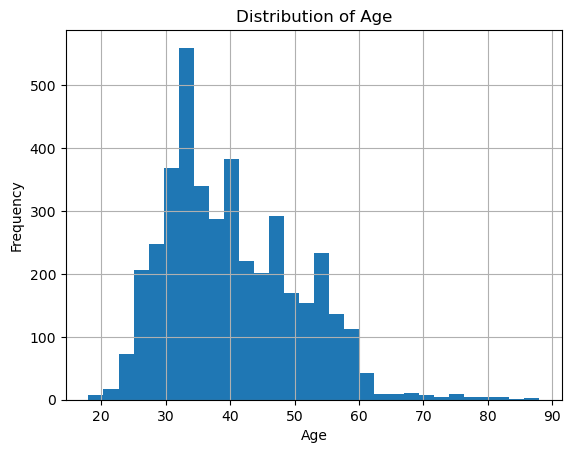

In [29]:
import matplotlib.pyplot as plt

df["age"].hist(bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

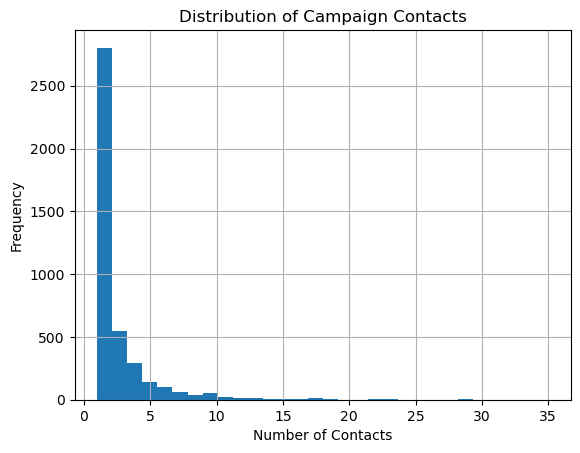

In [30]:
df["campaign"].hist(bins=30)
plt.title("Distribution of Campaign Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")
plt.show()

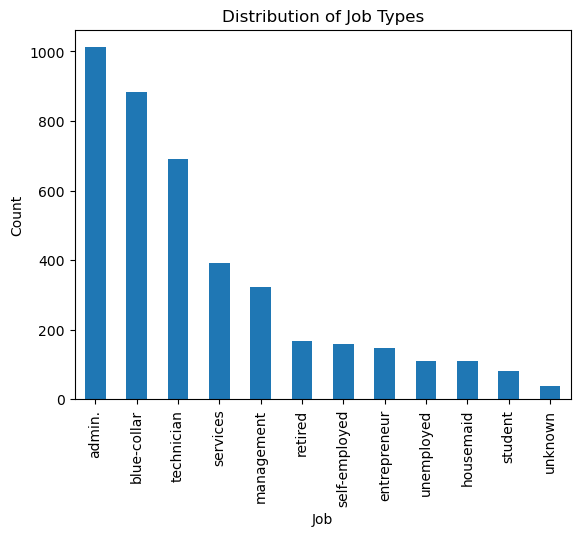

In [31]:
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of Job Types")
plt.xlabel("Job")
plt.ylabel("Count")
plt.show()

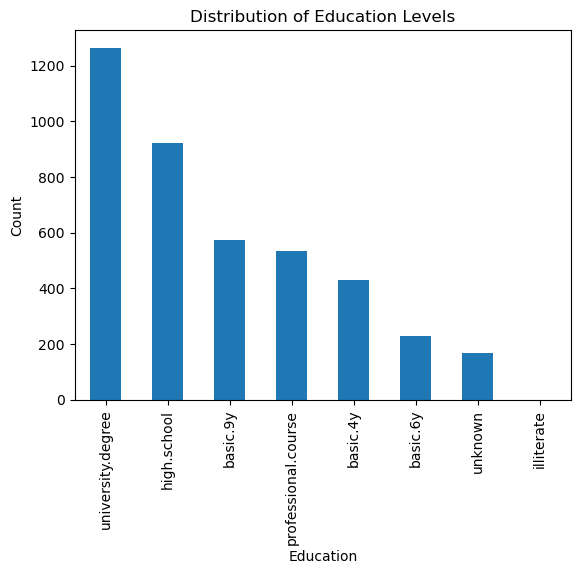

In [32]:
df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Levels")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

One variable that requires special consideration is **duration**, which represents the length of the phone call.

Although this variable is highly predictive of whether a client subscribes to a term deposit, it is only known after the call has finished. Because the prediction should be made at the time of contact, using this variable would introduce data leakage. Therefore, it should not be used as a predictor in the model.

Another variable that requires attention is **pdays**, which indicates the number of days since the client was last contacted. The value 999 represents that the client was not previously contacted, which acts as a sentinel value rather than a true numerical measurement. This will require careful handling during preprocessing.